# Group 1 - Compare the models

Run after notebooks 02-04. This chooses a model using validation results, then checks all three models on the test photos and displays the comparison and charts.

The saved outputs are from `group1_repro_v1`. To train again, follow the [setup guide](../project/SETUP.md). Its command runs all five notebooks with one new experiment name and keeps the submitted results unchanged.


In [1]:
from pathlib import Path
import os, sys
ROOT = Path.cwd().resolve()
if not (ROOT / "project" / "src").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "project" / "src" / "pipeline.py").exists(), "Open this notebook from the cloned repository."
PROJECT = ROOT / "project"
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
from src.pipeline import Experiment, IDS, MODEL_NAMES
DATA_DIR = Path(os.environ.get("CELEBA_DATA_DIR", str(ROOT / "data" / "identities")))
RUN_ID = os.environ.get("GROUP1_RUN_ID", "group1_repro_v1")
experiment = Experiment(DATA_DIR, RUN_ID)
print("Classes:", IDS, "\nData:", DATA_DIR, "\nRun:", RUN_ID)


Classes: ['7007', '2970', '2336', '7', '4428'] 
Data: C:\Users\Yose\IE7615-Group1-Project1\data\identities 
Run: group1_repro_v1


In [2]:
import json
import pandas as pd
records = [json.loads(experiment.path("logs", n + "_run.json").read_text()) for n in MODEL_NAMES]
selected = max(records, key=lambda r: r["validation_accuracy"])["architecture"]
print("Validation-selected model:", selected)
from src.pipeline import write_json
write_json(experiment.path("results", "selection.json"), {"selected_model":selected,"criterion":"highest validation accuracy at minimum-validation-loss checkpoint; ties use MODEL_NAMES order","selected_before_test_evaluation":True})


Validation-selected model: resnet18_frozen_backbone


In [3]:
results = [experiment.evaluate(n) for n in MODEL_NAMES]
columns = ["architecture", "selected_epoch", "validation_accuracy", "test_accuracy",
           "test_correct", "test_images", "total_parameters", "trainable_parameters",
           "training_seconds"]
if all("inference_ms_per_image" in r for r in results):
    columns.append("inference_ms_per_image")
comparison = pd.DataFrame([{k: r[k] for k in columns} for r in results])
out = experiment.path("results", "model_comparison.csv")
# Preserve the saved comparison, including any separately measured timing data.
if not out.exists():
    comparison.to_csv(out, index=False)
comparison

,architecture,selected_epoch,validation_accuracy,test_accuracy,test_correct,test_images,total_parameters,trainable_parameters,training_seconds,inference_ms_per_image
0,small_custom_cnn,30,0.266667,0.333333,5,15,19717,19717,92.026141,11.5320
1,deeper_custom_cnn,21,0.266667,0.400000,6,15,389701,389701,146.018965,18.0997
2,resnet18_frozen_backbone,28,0.800000,0.666667,10,15,11179077,2565,115.762959,35.2505


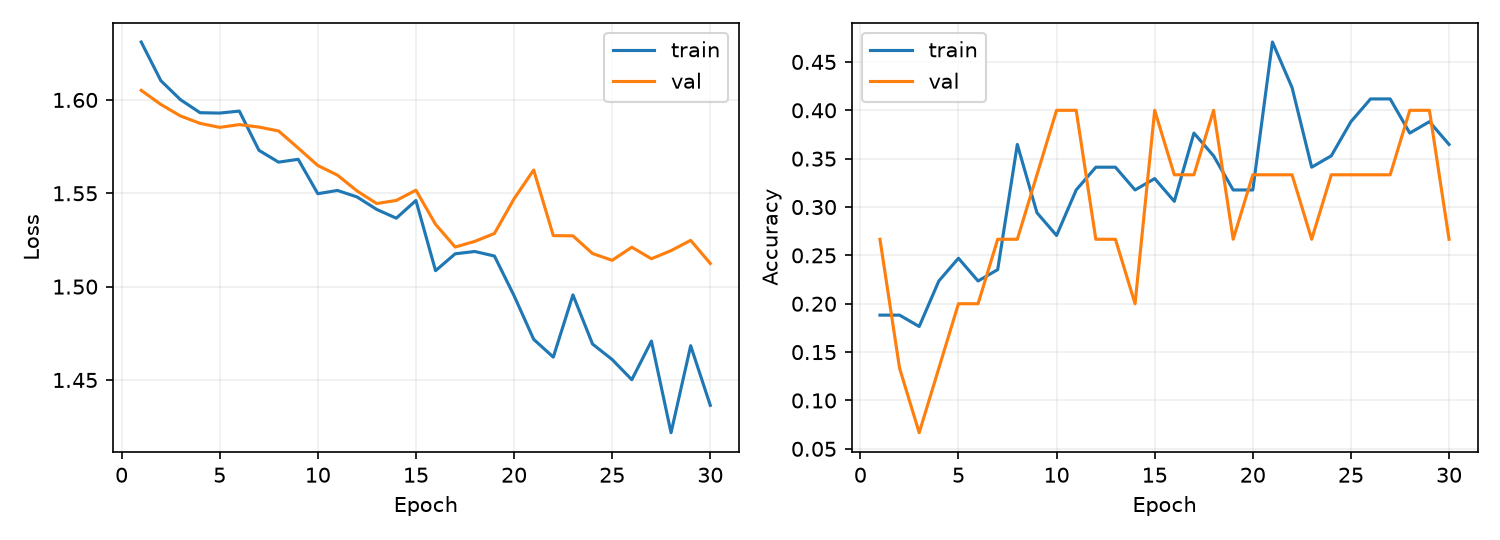

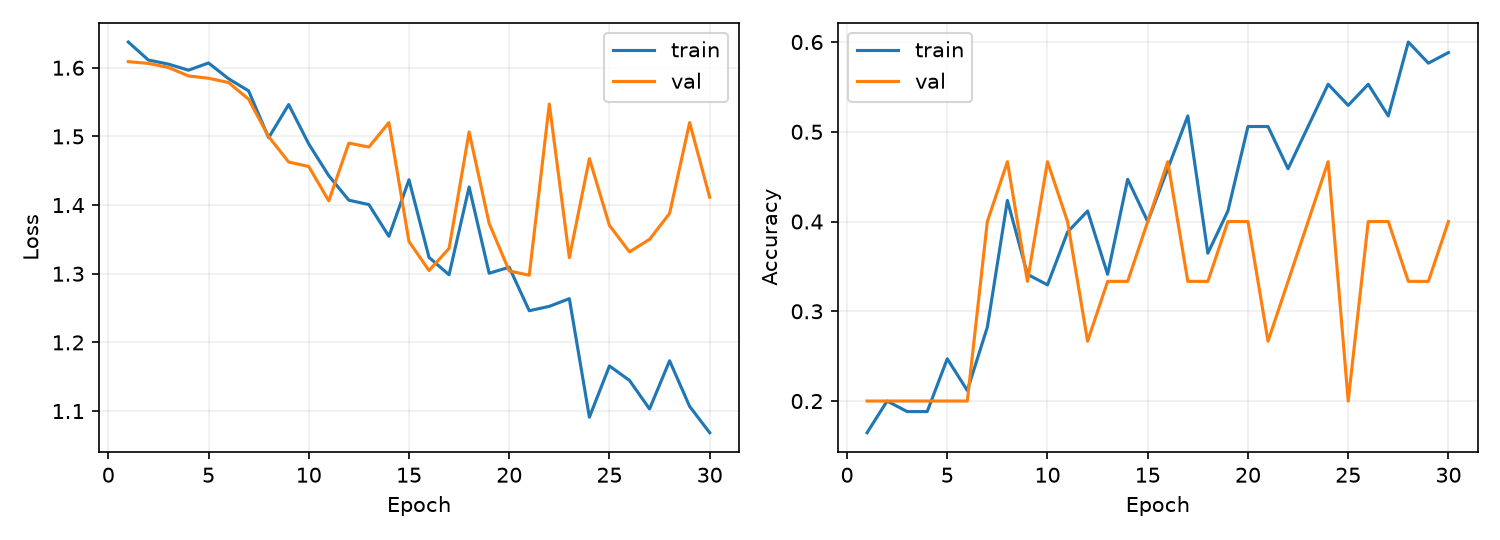

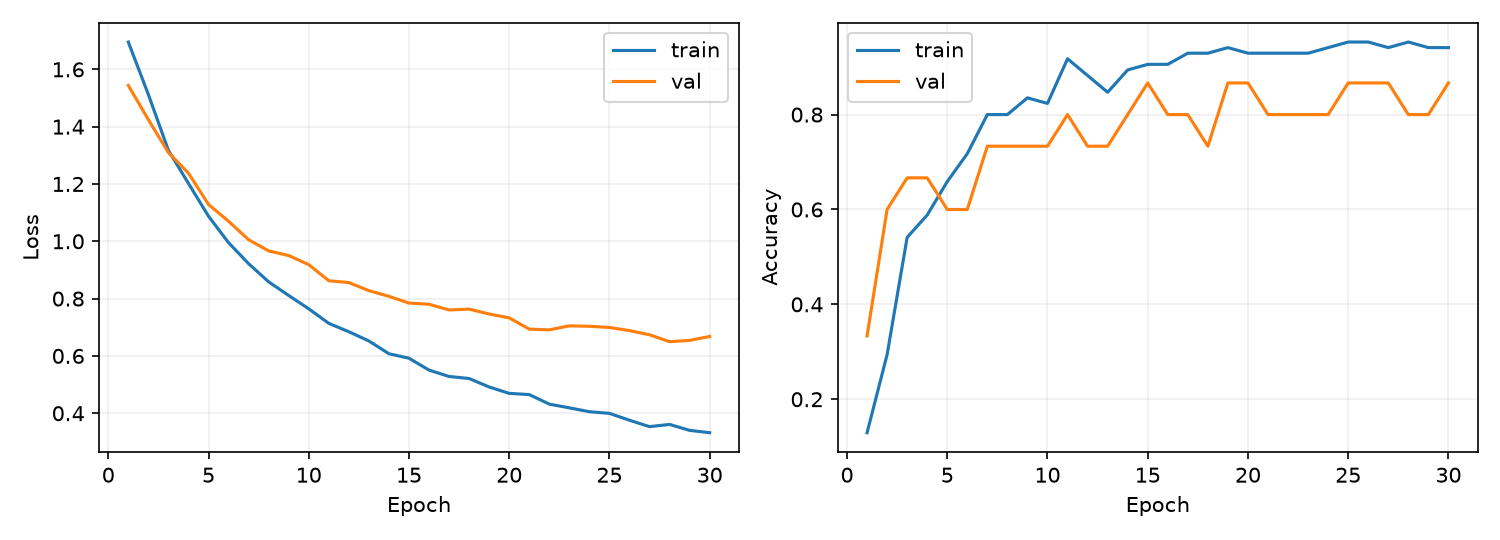

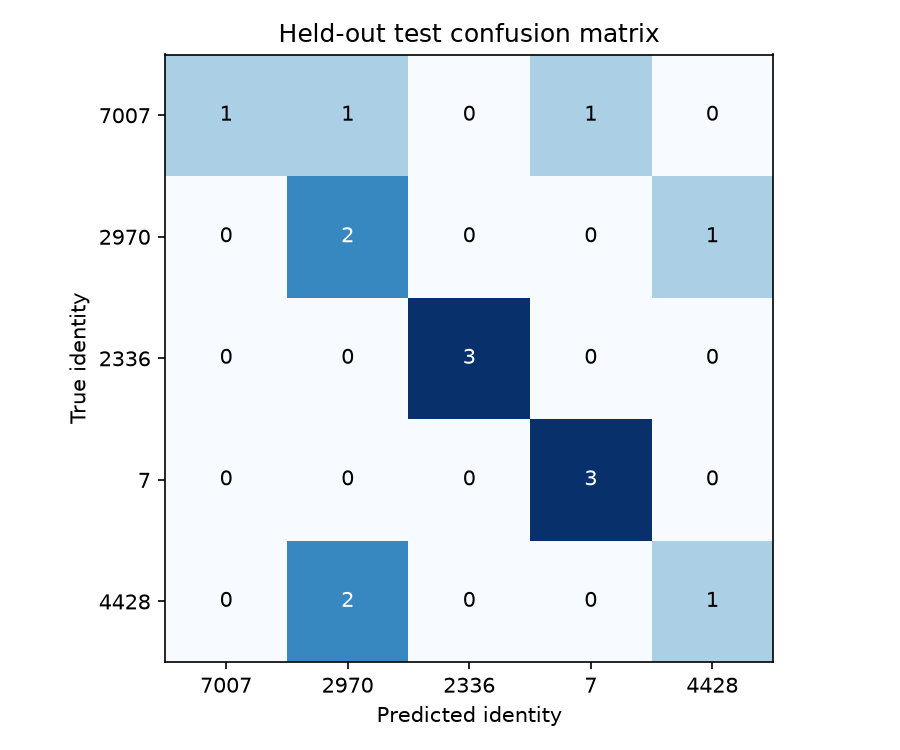

In [4]:
from IPython.display import Image, display
for name in MODEL_NAMES:
    display(Image(filename=str(experiment.path("results",name+"_curves.png"))))
display(Image(filename=str(experiment.path("results",selected+"_confusion.png"))))